# Sedimentation

In [17]:
from trustutils.jupyter import run

run.introduction("A. Gerschenfeld, Y. Gorsse")

run.TRUST_parameters()

## Introduction 
 Validation made by : A. Gerschenfeld, Y. Gorsse



 Report generated 14/12/2025

### TRUST parameters 
 * Version TRUST: 1.9.7
 * Binary used: /Volumes/codes/tnk/TRUST_NK_opt (built in directory /Volumes/codes/trust/Validation/Rapports_automatiques/Verification/Multiphase/sedimentation/build)

### Description: 

Cas tests de sedimentation. Etat initial melange, et separation des phases par gravite.

In [18]:
import os
from string import Template
run.useMEDCoupling()
import medcoupling as mc

meshes_dir = os.environ["TRUST_ROOT"] + "/Validation/Rapports_automatiques/Verification/PolyMAC/share/meshes"

cases = {("Cartesian", 5) : ["PolyVEF_P0", "VDF"], ("Triangles", 5) : ["PolyVEF_P0"], ("Quadrangles", 5) : ["PolyVEF_P0"]}
virtual_mass = { "no_vm" : " "} #, "vm" : " masse_ajoutee coef_constant { beta 0.5 } " }
run.reset()
run.initBuildDirectory()

for (case, n_mesh), diss in cases.items():
    for dis in diss:
        for (vm, string_vm) in virtual_mass.items() :
            os.system(f"mkdir -p {run.BUILD_DIRECTORY}/{case}/{dis}/{vm}")
            with open(f"{run.BUILD_DIRECTORY}/sep.data", "r") as file: filedata = Template(file.read())
            result = filedata.substitute({"dis" : dis, "virtual_mass" : string_vm})
            with open(f"{run.BUILD_DIRECTORY}/{case}/{dis}/{vm}/jdd.data", "w") as file: file.write(result)
            if not dis.startswith("Poly"):
                os.system(f"gunzip -c {meshes_dir}/{case}/jdd_{n_mesh}/mesh.med.gz >{run.BUILD_DIRECTORY}/{case}/{dis}/{vm}/mesh.med")
                meshname = f"{run.BUILD_DIRECTORY}/{case}/{dis}/{vm}/mesh.med"
                mfum = mc.MEDFileUMesh(meshname)
                mfum.getMeshAtLevel(0).unPolyze()
                mfum.write(meshname, 2)
            else: os.system(f"gunzip -c {meshes_dir}/{case}/jdd_{n_mesh}/mesh.med.gz >{run.BUILD_DIRECTORY}/{case}/{dis}/{vm}/mesh.med")

            run.addCase(f"{case}/{dis}/{vm}" ,"jdd.data")

run.printCases()
run.runCases()
run.tablePerf()

### Test cases 
* Cartesian/PolyVEF_P0/no_vm/jdd.data 
* Cartesian/VDF/no_vm/jdd.data 
* Triangles/PolyVEF_P0/no_vm/jdd.data 
* Quadrangles/PolyVEF_P0/no_vm/jdd.data 


Running **with Sserver**...
  => A total of 4 cases were (successfully) run in 1691.4s.


,host,system,Total CPU Time,CPU time/step,number of cells
Cartesian/PolyVEF_P0/no_vm/jdd,mac.home,Darwin,93.9111,0.0702385,4096
Cartesian/VDF/no_vm/jdd,mac.home,Darwin,31.8489,0.0317557,4096
Triangles/PolyVEF_P0/no_vm/jdd,mac.home,Darwin,1691.1100,0.52857,25872
Quadrangles/PolyVEF_P0/no_vm/jdd,mac.home,Darwin,109.1800,0.0779933,4096
Total,,,1926.0500,,


## Resultats

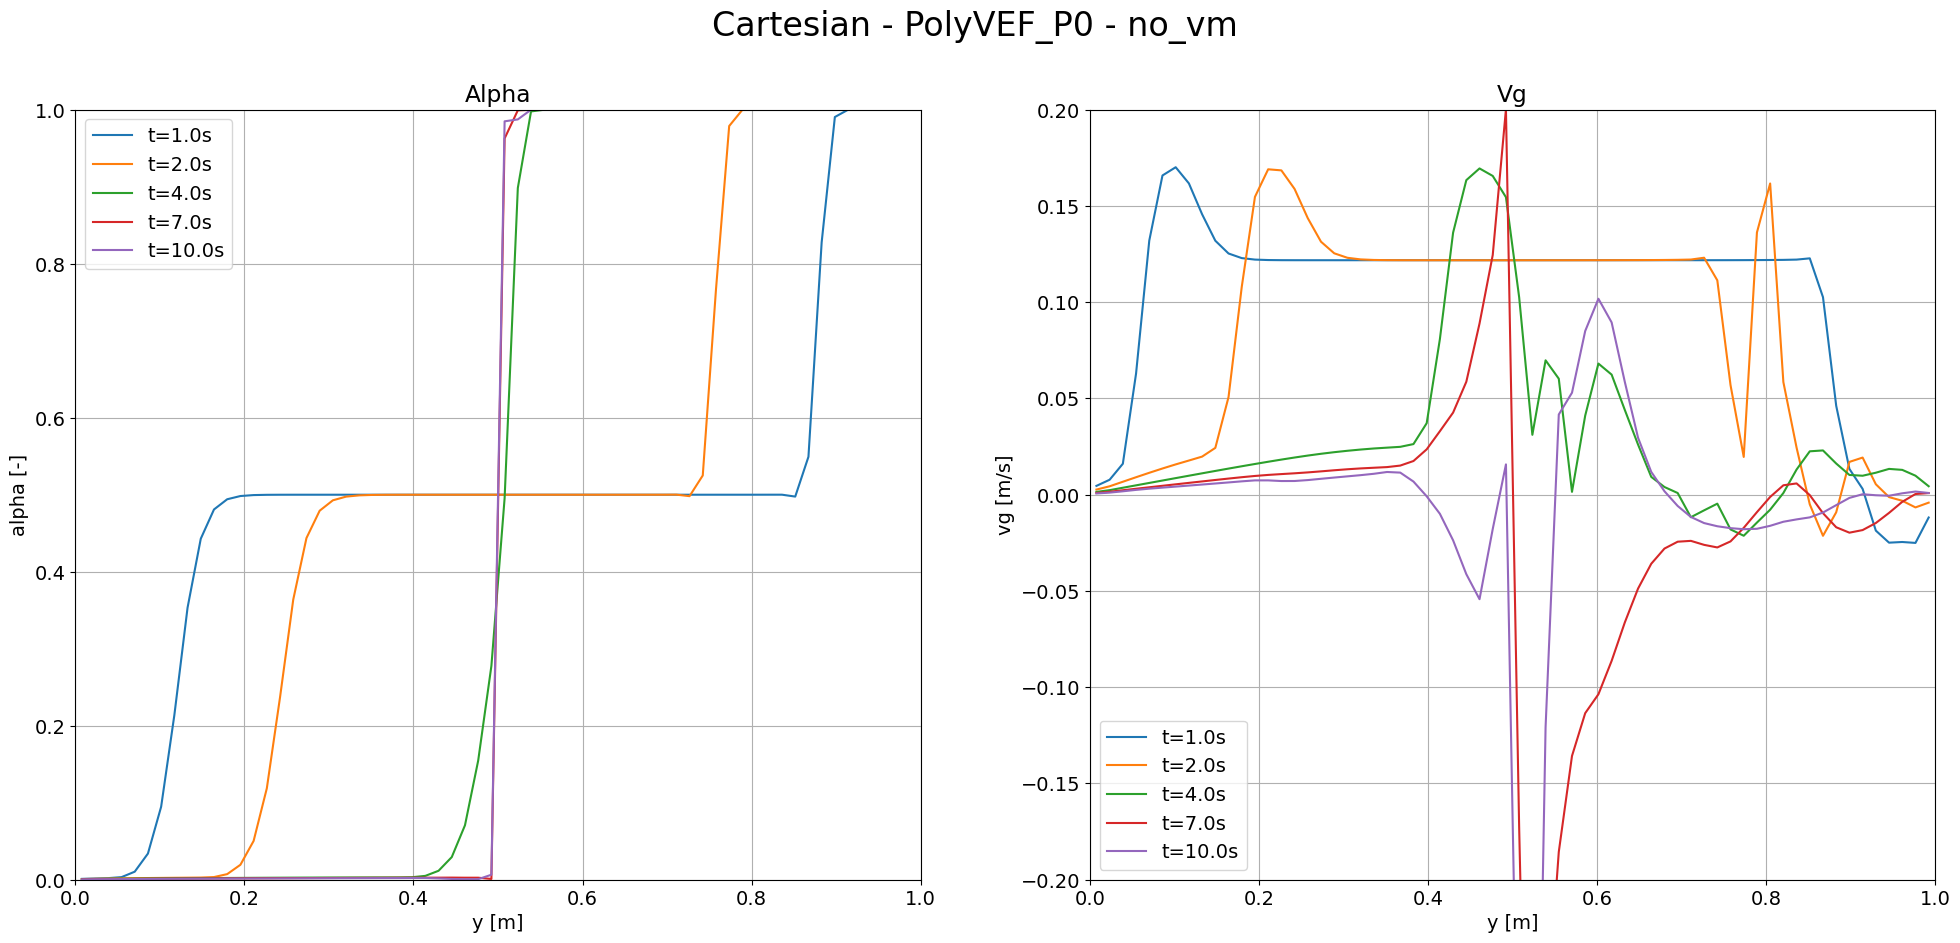

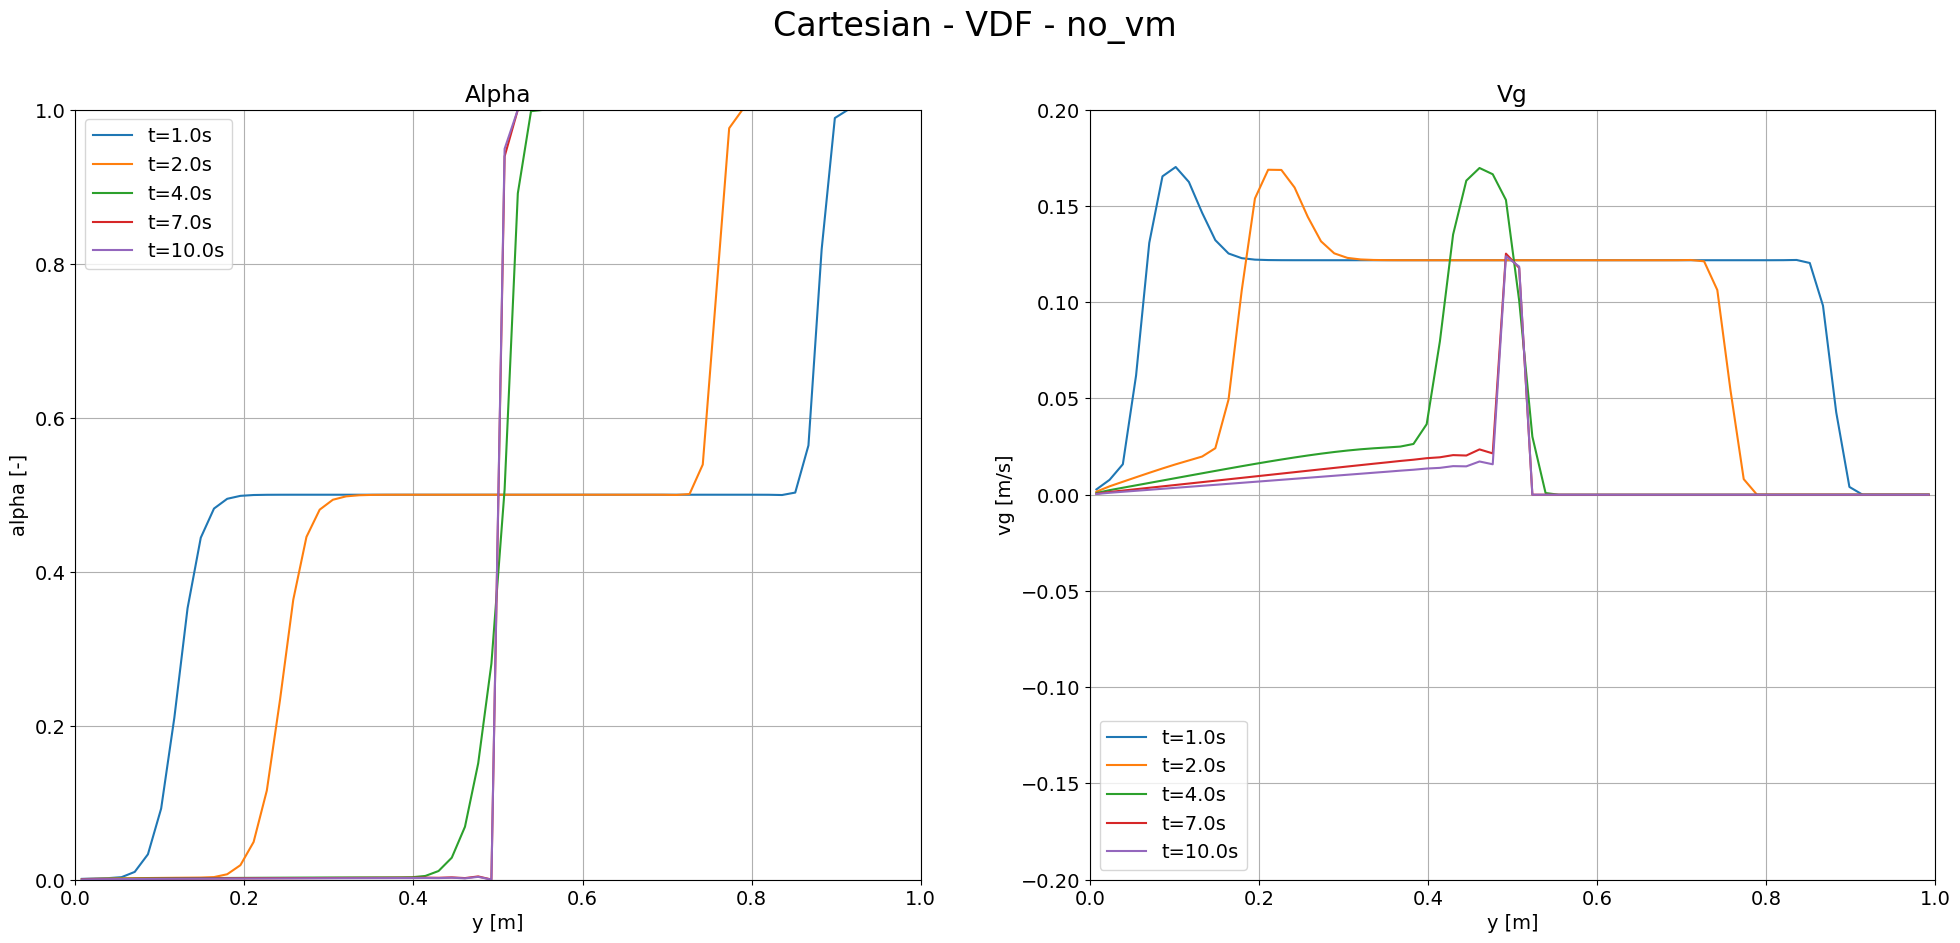

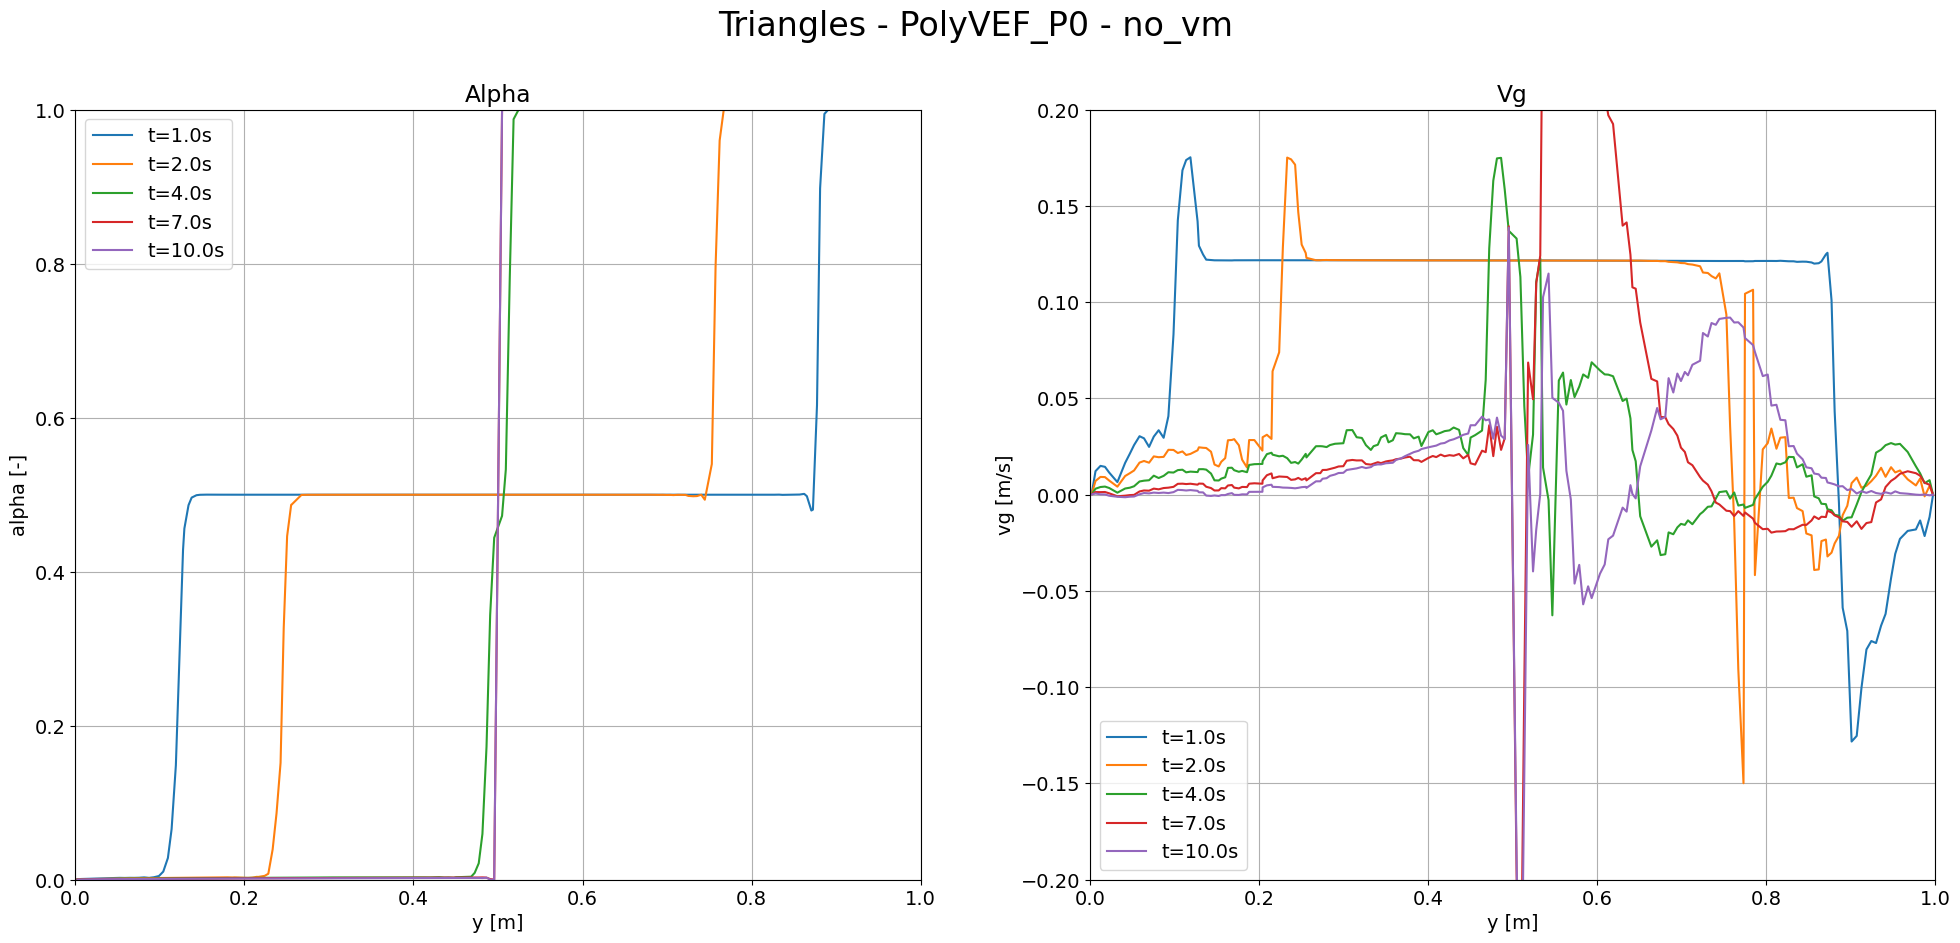

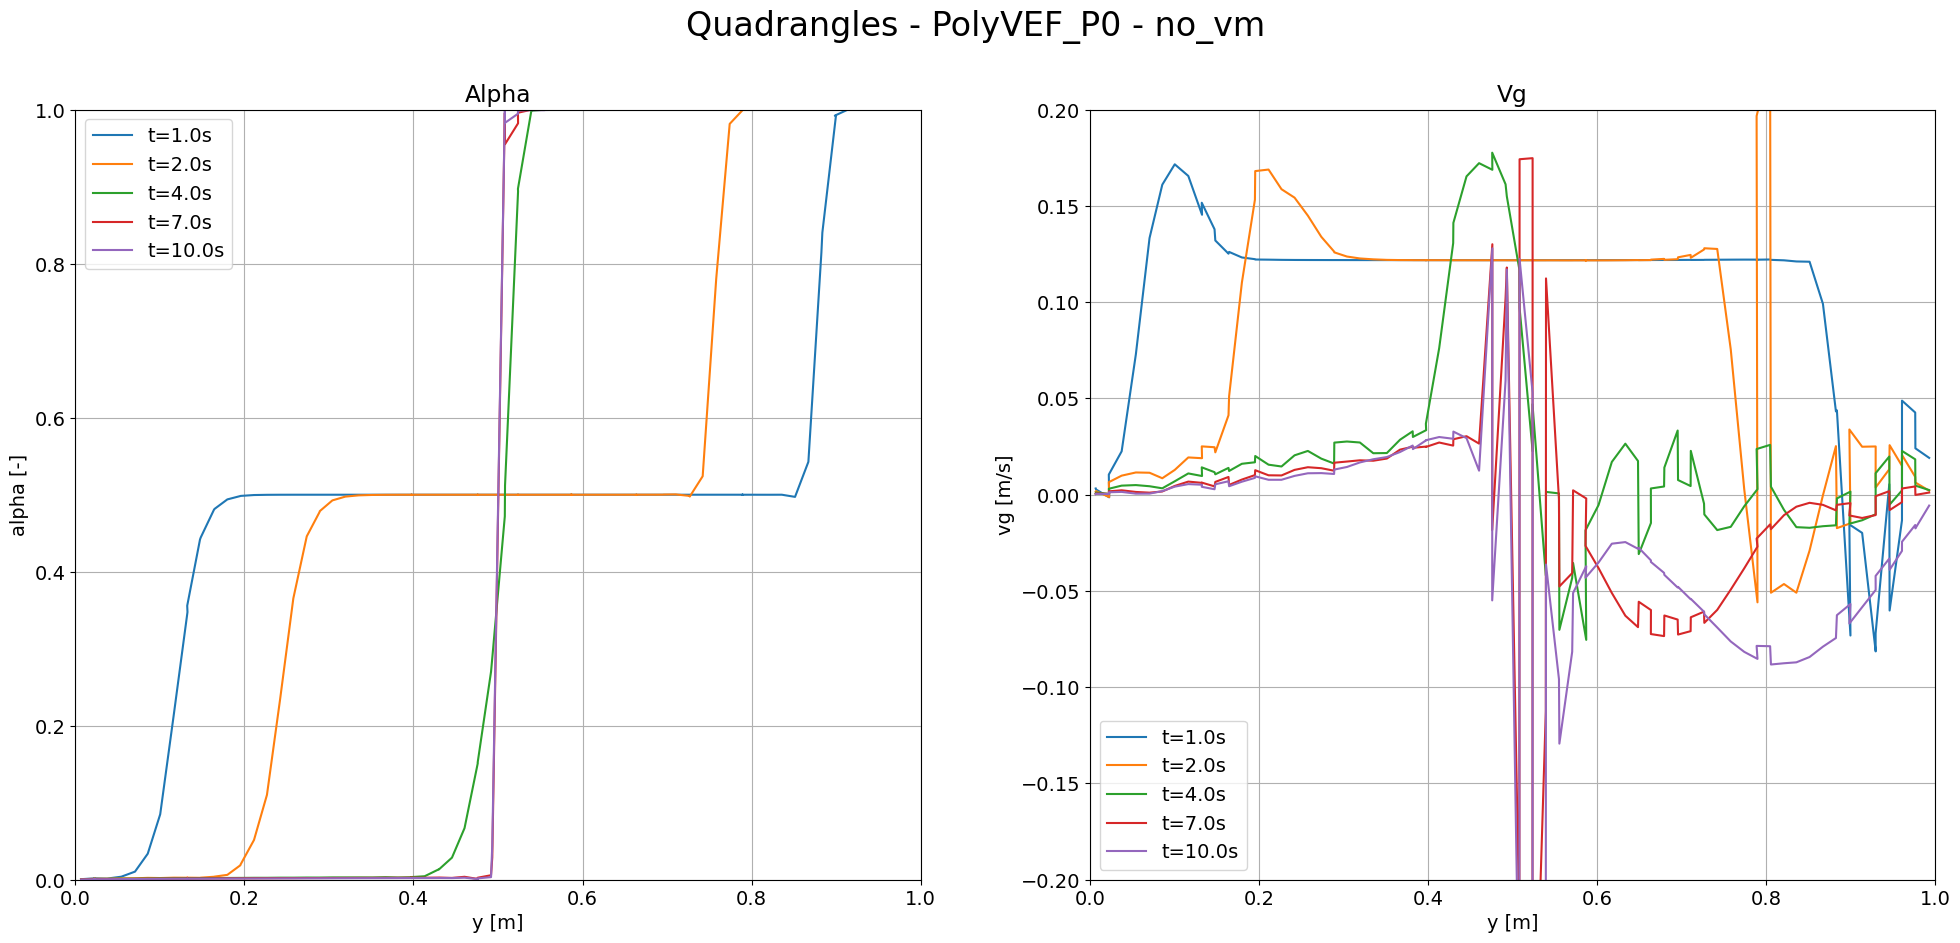

In [19]:
from trustutils import plot

times = [1.0, 2.0, 4.0, 7.0, 10.0]

for (case, _), diss in cases.items():
    for dis in diss:
        for vm in virtual_mass.keys() :
            a = plot.Graph(f"{case} - {dis} - {vm}", nY=2)
            for t in times:
                a.addPlot(0, "Alpha")
                a.addSegment(f"{case}/{dis}/{vm}/jdd_ALPHA.son", time=t, label=f"t={t}s")
                a.label("y [m]","alpha [-]")
                a.visu(0,1,0,1)

                a.addPlot(1, "Vg")
                a.addSegment(f"{case}/{dis}/{vm}/jdd_PROFIL_VG.son", compo=1, time=t, label=f"t={t}s")
                a.label("y [m]","vg [m/s]")
                a.visu(0,1,-0.2,0.2)


ValueError: addSegment : The path (/Volumes/codes/trust/Validation/Rapports_automatiques/Verification/Multiphase/sedimentation/build/Triangles/VDF/no_vm/jdd_ALPHA.son) does not exist!

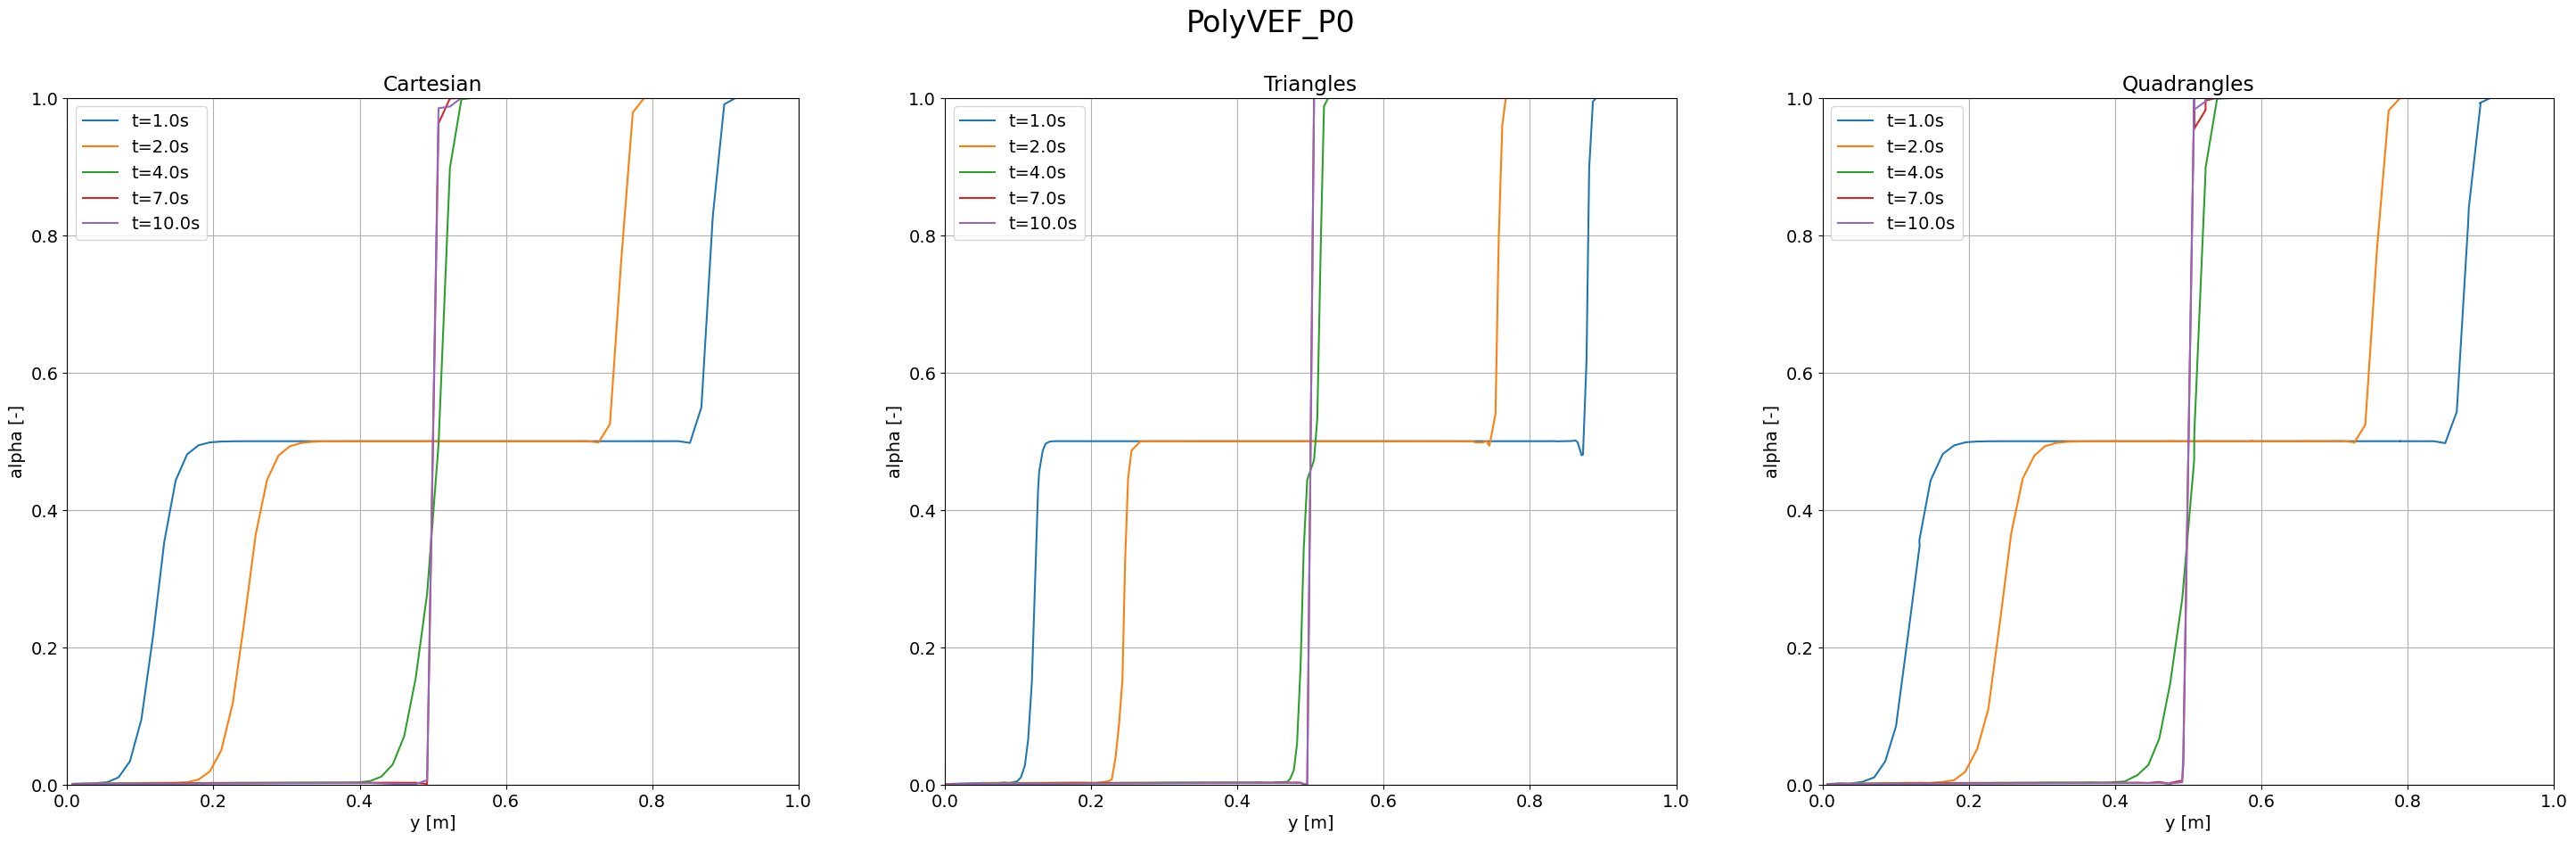

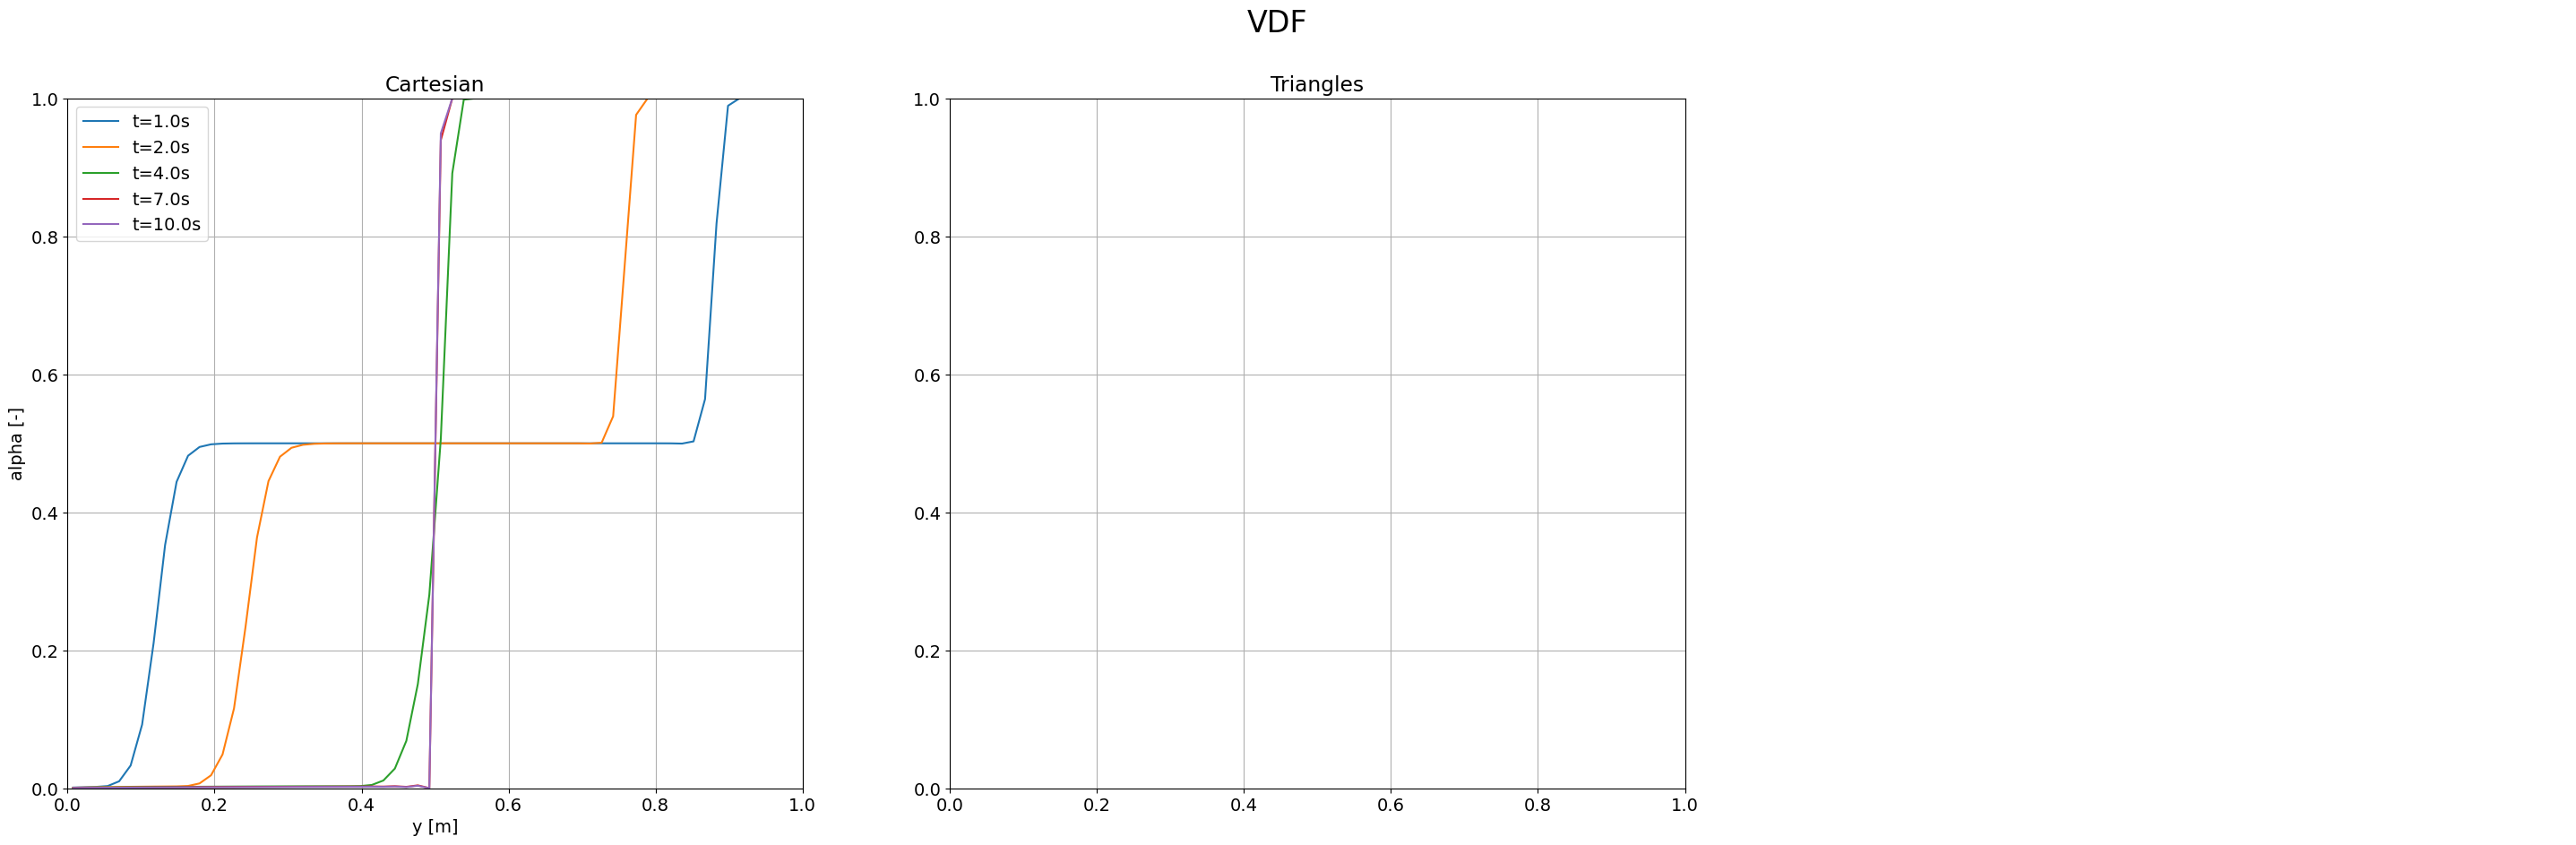

In [26]:

for j, ((case, _), diss) in enumerate(cases.items()):
    for dis in diss:
        a = plot.Graph(dis, nY=3)
        for i, ((case, _), diss) in enumerate(cases.items()):
            a.addPlot(i, case)
            for t in times:
                a.addSegment(f"{case}/{dis}/no_vm/jdd_ALPHA.son", time=t, label=f"t={t}s")
                a.label("y [m]","alpha [-]")
                a.visu(0,1,0,1)